<a href="https://colab.research.google.com/github/pleyva2004/Numerical-Linear-Algebra/blob/main/ExW9PabloLeyva.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gradient Descent Intro
 <p>

In [1]:
%matplotlib inline
import math,sys,os,numpy as np
from numpy.random import random
from matplotlib import pyplot as plt, rcParams, animation, rc
from __future__ import print_function, division
from ipywidgets import interact, interactive, fixed
from ipywidgets.widgets import *
rc('animation', html='html5')
rcParams['figure.figsize'] = 3, 3
%precision 4
np.set_printoptions(precision=4, linewidth=100)

In [2]:
def lin(a,b,x): return a*x+b

In [3]:
a=3.
b=8.

In [4]:
n=30
x = random(n)
y = lin(a,b,x) + np.random.randn(30)*0.1

In [5]:
x

array([0.9955, 0.2885, 0.5548, 0.927 , 0.5058, 0.4671, 0.636 , 0.015 , 0.4203, 0.5872, 0.9808,
       0.1221, 0.1612, 0.9901, 0.4236, 0.5081, 0.2203, 0.6731, 0.7997, 0.8037, 0.2879, 0.0129,
       0.8479, 0.2481, 0.9146, 0.5901, 0.6479, 0.9745, 0.597 , 0.4769])

In [6]:
y

array([10.8307,  8.7747,  9.7996, 10.6685,  9.6028,  9.4359,  9.8536,  8.0021,  9.2034,  9.9111,
       10.9177,  8.5075,  8.6058, 10.9178,  9.2885,  9.5836,  8.6669,  9.8562, 10.3462, 10.5015,
        8.6283,  8.0272, 10.6276,  8.554 , 10.7309,  9.6604,  9.8397, 10.9023,  9.6166,  9.5646])

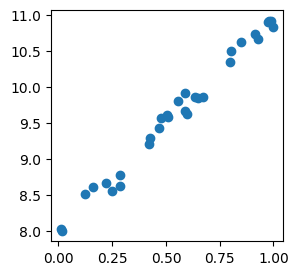

In [7]:
plt.scatter(x,y)

In [8]:
def sse(y,y_pred): return ((y-y_pred)**2).sum()
def loss(y,a,b,x): return sse(y, lin(a,b,x))
def avg_loss(y,a,b,x): return np.sqrt(loss(y,a,b,x)/n)

In [9]:
a_guess=-1.
b_guess=1.
avg_loss(y, a_guess, b_guess, x)

np.float64(9.276868065445074)

In [10]:
lr=0.01
# d[(y-(a*x+b))**2,b] = 2 (b + a x - y)      = 2 (y_pred - y)
# d[(y-(a*x+b))**2,a] = 2 x (b + a x - y)    = x * dy/db

In [ ]:
def upd():
    global a_guess, b_guess

    # Randomly select a data point
    random_i = int(np.random.uniform(0,n))

    # make a prediction using the current weights
    y_pred = lin(a_guess, b_guess, x[random_i])

    # calculate the derivate of the loss
    dydb = 2 * (y_pred - y[random_i])
    dyda = x[random_i] * dydb

    # update our weights by moving in direction of steepest descent
    a_guess -= lr*dyda
    b_guess -= lr*dydb
    return a_guess, b_guess, avg_loss(y, a_guess, b_guess, x)

In [12]:
fig = plt.figure(dpi=100, figsize=(5, 4))
plt.scatter(x,y)
line, = plt.plot(x,lin(a_guess,b_guess,x))
plt.close()

cost = []
a_comp = []
b_comp = []

def animate(i):
    line.set_ydata(lin(a_guess,b_guess,x))
    for i in range(10):
      a_pred, b_pred, err = upd()
      cost.append(err)
      a_comp.append(a_pred)
      b_comp.append(b_pred)
    return line,

ani = animation.FuncAnimation(fig, animate, np.arange(0, 40), interval=100)
ani

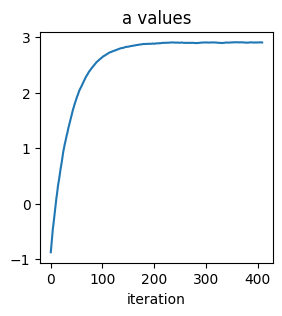

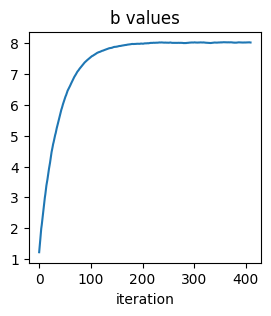

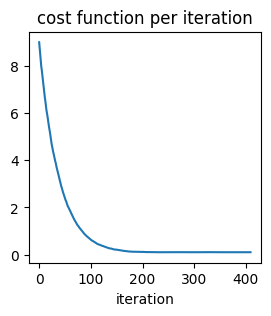

In [13]:
plt.plot(a_comp)
plt.title('a values')
plt.xlabel('iteration')
plt.show()

plt.plot(b_comp)
plt.title('b values')
plt.xlabel('iteration')
plt.show()

plt.plot(cost)
plt.title('cost function per iteration')
plt.xlabel('iteration')
plt.show()